In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [2]:
data_saatlik = pd.read_excel("Elektrik_uretim_tuketim_saatlik.xlsx")

data_saatlik = data_saatlik.set_index("DateTime")
data_saatlik.index = pd.to_datetime(data_saatlik.index)

# Makine Öğrenimi (Saatlik veri kullanıldı)

In [3]:
# Modellerin eğitiminde 12 aylık saatlik veri kullanıldı.
m_data_saatlik = data_saatlik.copy()

In [4]:
m_data_saatlik.head(10)

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30
2019-01-01 05:00:00,5525,5385,1395,91,958,1455,1456,0,30
2019-01-01 06:00:00,5513,5349,1392,98,938,1451,1440,0,31
2019-01-01 07:00:00,5524,5547,1392,93,1187,1446,1394,0,34
2019-01-01 08:00:00,5510,5471,1391,51,1325,1357,1303,8,34


In [5]:
m_data_saatlik["lag_1"]  = m_data_saatlik["Consumption"].shift(1)
m_data_saatlik["lag_7"]  = m_data_saatlik["Consumption"].shift(7)
m_data_saatlik["lag_14"] = m_data_saatlik["Consumption"].shift(14)
m_data_saatlik["lag_30"] = m_data_saatlik["Consumption"].shift(30)

m_data_saatlik["roll_7"]  = m_data_saatlik["Consumption"].rolling(7).mean()
m_data_saatlik["roll_14"] = m_data_saatlik["Consumption"].rolling(14).mean()
m_data_saatlik["roll_30"] = m_data_saatlik["Consumption"].rolling(30).mean()

m_data_saatlik["dow"]   = m_data_saatlik.index.dayofweek
m_data_saatlik["month"] = m_data_saatlik.index.month
m_data_saatlik["week"]  = m_data_saatlik.index.isocalendar().week.astype(int)

In [6]:
m_data_saatlik.isna().sum()

Consumption       0
Production        0
Nuclear           0
Wind              0
Hydroelectric     0
Oil and Gas       0
Coal              0
Solar             0
Biomass           0
lag_1             1
lag_7             7
lag_14           14
lag_30           30
roll_7            6
roll_14          13
roll_30          29
dow               0
month             0
week              0
dtype: int64

In [7]:
m_data_saatlik = m_data_saatlik.dropna()

In [8]:
m_data_saatlik.isna().sum()

Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
lag_1            0
lag_7            0
lag_14           0
lag_30           0
roll_7           0
roll_14          0
roll_30          0
dow              0
month            0
week             0
dtype: int64

In [9]:
m_train_saat = m_data_saatlik.loc[(m_data_saatlik.index >= "2024-03-01") & (m_data_saatlik.index <  "2025-01-01")]

m_test_saat = m_data_saatlik.loc[m_data_saatlik.index >= "2025-01-01"]

In [10]:
m_train_saat.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,lag_1,lag_7,lag_14,lag_30,roll_7,roll_14,roll_30,dow,month,week
DateTime,,,,,,,,,,,,,,,,,,,
2024-03-01 00:00:00,5830,6014,1378,783,1525,1534,739,0,55,6165.0,7104.0,7273.0,7389.0,6967.571429,7029.714286,6743.433333,4,3,9
2024-03-01 01:00:00,5780,6186,1383,896,1531,1668,653,0,55,5830.0,7578.0,7171.0,7729.0,6710.714286,6930.357143,6678.466667,4,3,9
2024-03-01 02:00:00,5617,6127,1383,968,1427,1639,654,0,56,5780.0,7708.0,7169.0,7628.0,6412.000000,6819.500000,6611.433333,4,3,9
2024-03-01 03:00:00,5600,6234,1382,1001,1520,1620,653,0,58,5617.0,7635.0,7169.0,7300.0,6121.285714,6707.428571,6554.766667,4,3,9
2024-03-01 04:00:00,5656,6112,1384,828,1552,1631,661,0,56,5600.0,7217.0,7025.0,6640.0,5898.285714,6609.642857,6521.966667,4,3,9


In [11]:
m_test_saat.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,lag_1,lag_7,lag_14,lag_30,roll_7,roll_14,roll_30,dow,month,week
DateTime,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,5771,5289,1384,680,852,1621,723,0,37,6069.0,7580.0,6694.0,7840.0,6657.000000,6705.214286,6412.666667,2,1,1
2025-01-01 01:00:00,5610,5325,1389,691,878,1624,693,0,37,5771.0,7587.0,6592.0,7677.0,6374.571429,6635.071429,6343.766667,2,1,1
2025-01-01 02:00:00,5444,5346,1386,724,872,1624,698,0,38,5610.0,7283.0,6508.0,7474.0,6111.857143,6559.071429,6276.100000,2,1,1
2025-01-01 03:00:00,5249,5446,1387,829,864,1616,700,0,38,5444.0,6959.0,6482.0,7133.0,5867.571429,6471.000000,6213.300000,2,1,1
2025-01-01 04:00:00,5143,5427,1386,944,848,1508,704,0,37,5249.0,6620.0,6527.0,6789.0,5656.571429,6372.142857,6158.433333,2,1,1


In [12]:
m_x_train_saat = m_train_saat.drop("Consumption", axis=1)
m_y_train_saat = m_train_saat["Consumption"]

m_x_test_saat  = m_test_saat.drop("Consumption", axis=1)
m_y_test_saat  = m_test_saat["Consumption"]

# RASTGELE AĞAÇLAR MODELİ

In [13]:
from sklearn.ensemble import RandomForestRegressor

In [14]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42,
)

rf.fit(m_x_train_saat, m_y_train_saat)

RandomForestRegressor(max_depth=12, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=500, random_state=42)

In [15]:
rf_y_pred = rf.predict(m_x_test_saat)

In [16]:
rf_mae = mean_absolute_error(m_y_test_saat, rf_y_pred)
rf_rmse = np.sqrt(mean_squared_error(m_y_test_saat, rf_y_pred))
rf_mape = np.mean(np.abs((m_y_test_saat - rf_y_pred) / m_y_test_saat)) * 100
rf_naive_error = np.mean(np.abs(m_y_train_saat.diff().dropna()))
rf_mase = rf_mae / rf_naive_error

In [17]:
rf_performance = pd.DataFrame({
    "Model": ["Random Forest"],
    "RF_MAE": [rf_mae],
    "RF_RMSE": [rf_rmse],
    "RF_MAPE (%)": [rf_mape],
    "RF_MASE": [rf_mase]
})

print(rf_performance)

           Model      RF_MAE     RF_RMSE  RF_MAPE (%)   RF_MASE
0  Random Forest  181.532126  268.611443     2.643745  0.793943


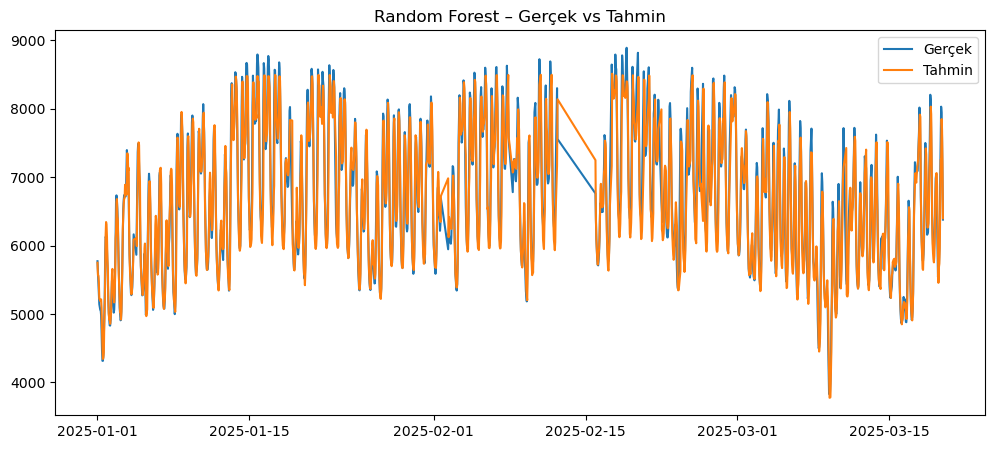

In [18]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(m_y_test_saat.index, m_y_test_saat, label="Gerçek")
plt.plot(m_y_test_saat.index, rf_y_pred, label="Tahmin")
plt.legend()
plt.title("Random Forest – Gerçek vs Tahmin")
plt.show()

# XGBOOST MODELİ

In [19]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(m_x_train_saat, m_y_train_saat)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [20]:
y_pred_xgb = xgb.predict(m_x_test_saat)

In [21]:
# # model performansı değerlendirme
mae_xgb = mean_absolute_error(m_y_test_saat, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(m_y_test_saat, y_pred_xgb))
mape_xgb = np.mean(np.abs((m_y_test_saat - y_pred_xgb) / m_y_test_saat)) * 100
xgb_naive_error = np.mean(np.abs(m_y_train_saat.diff().dropna()))
mase_xgb = mae_xgb / xgb_naive_error

In [22]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [mae_xgb],
    "RMSE": [rmse_xgb],
    "MAPE (%)": [mape_xgb],
    "MASE": [mase_xgb]
})

print(xgb_results)

     Model         MAE        RMSE  MAPE (%)      MASE
0  XGBoost  190.662168  268.470414  2.774201  0.833874


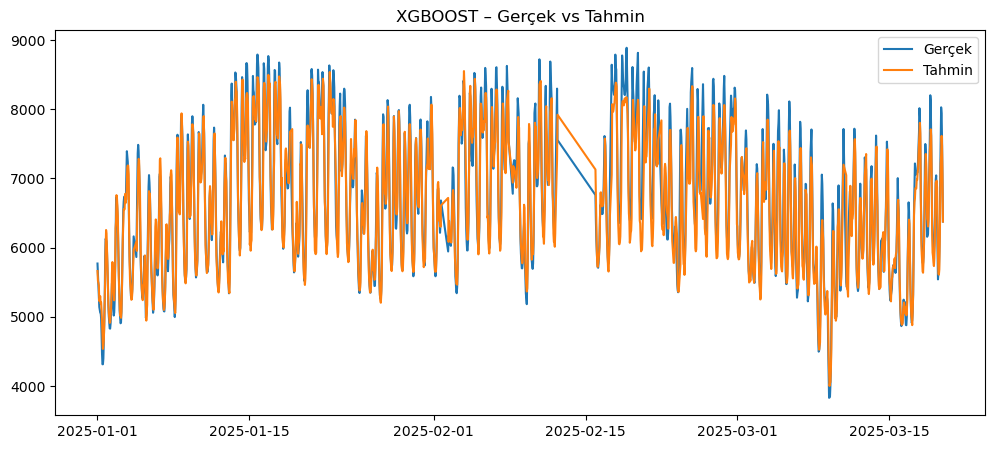

In [23]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(m_y_test_saat.index, m_y_test_saat, label="Gerçek")
plt.plot(m_y_test_saat.index, y_pred_xgb, label="Tahmin")
plt.legend()
plt.title("XGBOOST – Gerçek vs Tahmin")
plt.show()

# LİGHT GBM MODELİ

In [24]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(m_x_train_saat, m_y_train_saat)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001148 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3628
[LightGBM] [Info] Number of data points in the train set: 7200, number of used features: 18
[LightGBM] [Info] Start training from score 6071.425417


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              n_jobs=-1, random_state=42, subsample=0.8)

In [25]:
y_pred_lgbm = lgbm.predict(m_x_test_saat)

In [26]:
# MAE
mae_lgbm = mean_absolute_error(m_y_test_saat, y_pred_lgbm)

# RMSE
rmse_lgbm = np.sqrt(mean_squared_error(m_y_test_saat, y_pred_lgbm))

# MAPE (%)
mape_lgbm = np.mean(np.abs((m_y_test_saat - y_pred_lgbm) / m_y_test_saat)) * 100

# MASE (naive: t-1)
lgbm_naive_error = np.mean(np.abs(m_y_train_saat.diff().dropna()))
mase_lgbm = mae_lgbm / lgbm_naive_error

In [27]:
results_lgbm = pd.DataFrame({
    "Model": ["LightGBM"],
    "MAE": [mae_lgbm],
    "RMSE": [rmse_lgbm],
    "MAPE (%)": [mape_lgbm],
    "MASE": [mase_lgbm]
})

print(results_lgbm)

      Model         MAE        RMSE  MAPE (%)      MASE
0  LightGBM  207.905406  293.216622  2.978454  0.909288


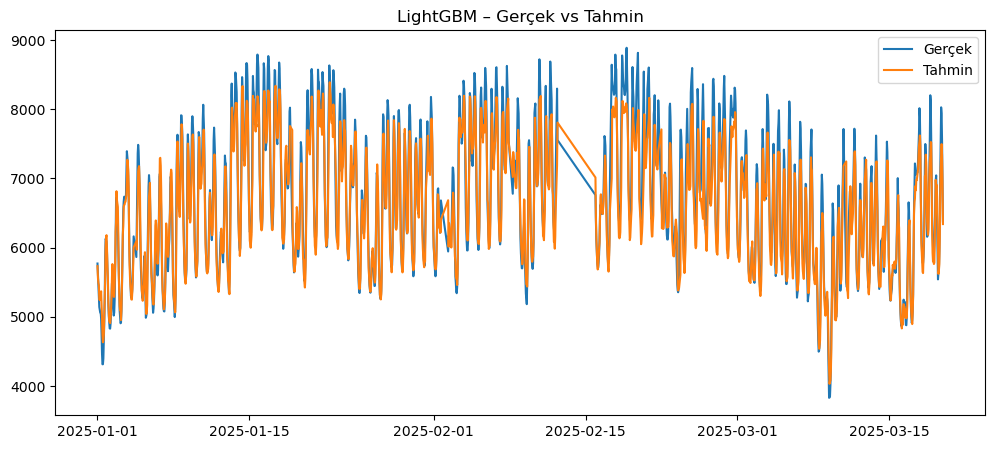

In [53]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(m_y_test_saat.index, m_y_test_saat, label="Gerçek")
plt.plot(m_y_test_saat.index, y_pred_lgbm, label="Tahmin")
plt.legend()
plt.title("LightGBM – Gerçek vs Tahmin")
plt.show()

# LSTM ve CNN modeli için veri hazırlama

In [29]:
# LSTM ve CNN modellerinde eğitim ve test veri setleri farklı ayrılıyor. Zamana bağımlılığı model kendisi öğreniyor.
# Modellerin eğitiminde 12 aylık saatlik veri kullanıldı.
d_data_saatlik = data_saatlik.copy()

In [30]:
d_train_saat = d_data_saatlik.loc[(d_data_saatlik.index >= "2024-03-01") & (d_data_saatlik.index <  "2025-01-01")]

d_test_saat = d_data_saatlik.loc[d_data_saatlik.index >= "2025-01-01"]

In [31]:
features = ["Production", "Nuclear", "Wind", "Hydroelectric", "Oil and Gas", "Coal", "Solar", "Biomass"]

In [32]:
d_x_train = d_train_saat.drop("Consumption", axis=1)
d_y_train = d_train_saat[["Consumption"]]

d_x_test  = d_train_saat.drop("Consumption", axis=1)
d_y_test  = d_train_saat[["Consumption"]]

In [33]:
# Sinir ağları modeli olduğu için ölçekleme yapmak zorundayız. Lakin bunu sadece eğitim verisi için yapıyoruz.
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

d_x_train_scaled = x_scaler.fit_transform(d_x_train)
d_x_test_scaled  = x_scaler.transform(d_x_test)

d_y_train_scaled = y_scaler.fit_transform(d_y_train)
d_y_test_scaled  = y_scaler.transform(d_y_test)

In [34]:
# 30 günlük bir pencere oluşturuldu.
def create_lstm_sequences(data, window_size=30):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW = 30

X_train_l, y_train_l = create_lstm_sequences(d_x_train_scaled, WINDOW)
X_test_l,  y_test_l  = create_lstm_sequences(d_x_test_scaled, WINDOW)

In [35]:
print(X_train_l.shape)
print(y_train_l.shape)

(7170, 30, 8)
(7170,)


# LSTM MODELİ

In [36]:
# LSTM modeli kurmak için gerekli kütüphaneler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [37]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_l.shape[1], X_train_l.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_l, y_train_l,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - loss: 0.0268 - val_loss: 0.0038
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0075 - val_loss: 0.0030
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0057 - val_loss: 0.0019
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0046 - val_loss: 0.0015
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0039 - val_loss: 0.0013
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0036 - val_loss: 9.6843e-04
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0031 - val_loss: 9.8834e-04
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0029 - val_loss: 8.9537e-04
Epoch 9/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 10/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 11/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0023 - val_loss: 6.6582e-04
Epoch 12/100


In [38]:
y_pred_scaled = model.predict(X_test_l)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


In [39]:
y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled)
y_test_real = y_scaler.inverse_transform(y_test_l.reshape(-1, 1))

In [40]:
lstm_mae  = mean_absolute_error(y_test_real, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_lstm))
lstm_mape = np.mean(np.abs((y_test_real - y_pred_lstm) / y_test_real)) * 100
# Naive forecast (t-1)
lstm_naive_forecast = y_test_real[:-1]
lstm_actual = y_test_real[1:]
lstm_mase = lstm_mae / np.mean(np.abs(lstm_actual - lstm_naive_forecast))

In [41]:
# Model performans başarısı
results_lstm = pd.DataFrame({
    "Model": ["LSTM"],
    "MAE": [lstm_mae],
    "RMSE": [lstm_rmse],
    "MAPE (%)": [lstm_mape],
    "MASE": [lstm_mase]
})

print(results_lstm)

  Model         MAE        RMSE  MAPE (%)      MASE
0  LSTM  124.846589  173.605824  2.414025  0.869466


In [42]:
y_test_reala = d_y_test.index[WINDOW:]

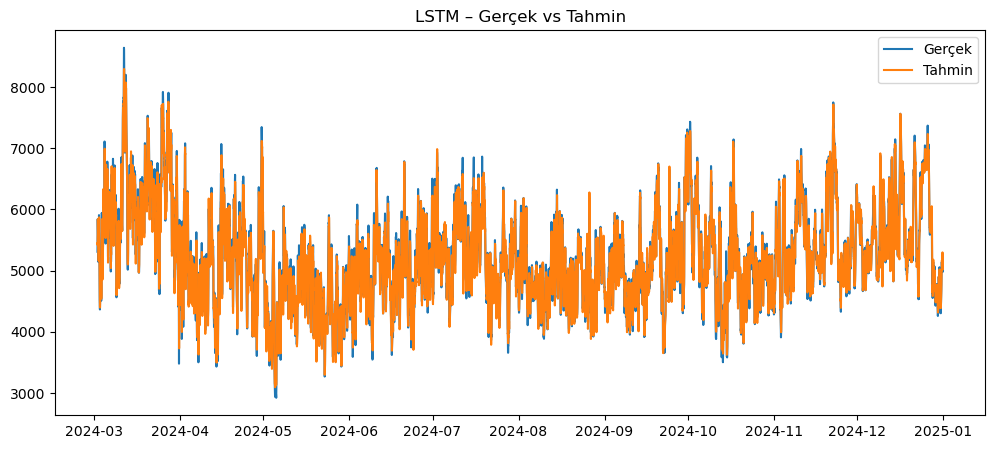

In [43]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(y_test_reala, y_test_real, label="Gerçek")
plt.plot(y_test_reala, y_pred_lstm, label="Tahmin")
plt.legend()
plt.title("LSTM – Gerçek vs Tahmin")
plt.show()

# CNN MODELİ

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping

In [45]:
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation="relu",
           input_shape=(X_train_l.shape[1], X_train_l.shape[2])),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=32, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(1)
])

cnn_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    X_train_l, y_train_l,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0216 - val_loss: 0.0040
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0063 - val_loss: 0.0034
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0047 - val_loss: 0.0030
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0045 - val_loss: 0.0015
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - val_loss: 0.0025
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033 - val_loss: 0.0016
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029 - val_loss: 0.0013
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 9/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0024 - val_loss: 0.0013
Epoch 10/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - val_loss: 0.0013
Epoch 11/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 12/100
202/202 ━━━━━━━━━━━━━━━━━━━━

In [46]:
# Tahmin
y_pred_cnn_scaled = cnn_model.predict(X_test_l)

y_pred_cnn = y_scaler.inverse_transform(y_pred_cnn_scaled)
y_test_real_cnn = y_scaler.inverse_transform(y_test_l.reshape(-1,1))

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [47]:
mae_cnn = mean_absolute_error(y_test_real_cnn, y_pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_test_real_cnn, y_pred_cnn))
mape_cnn = np.mean(np.abs((y_test_real_cnn - y_pred_cnn) / y_test_real_cnn)) * 100

# Naive forecast (t-1)
cnn_naive = y_test_real_cnn[:-1]
mase_cnn = mae_cnn / np.mean(np.abs(y_test_real_cnn[1:] - cnn_naive))

In [48]:
# Model performans başarısı
results_cnn = pd.DataFrame({
    "Model": ["CNN"],
    "MAE": [mae_cnn],
    "RMSE": [rmse_cnn],
    "MAPE (%)": [mape_cnn],
    "MASE": [mase_cnn]
})

print(results_cnn)

  Model         MAE        RMSE  MAPE (%)     MASE
0   CNN  126.393634  167.953618  2.445288  0.88024


In [49]:
y_test_realc = d_y_test.index[WINDOW:]

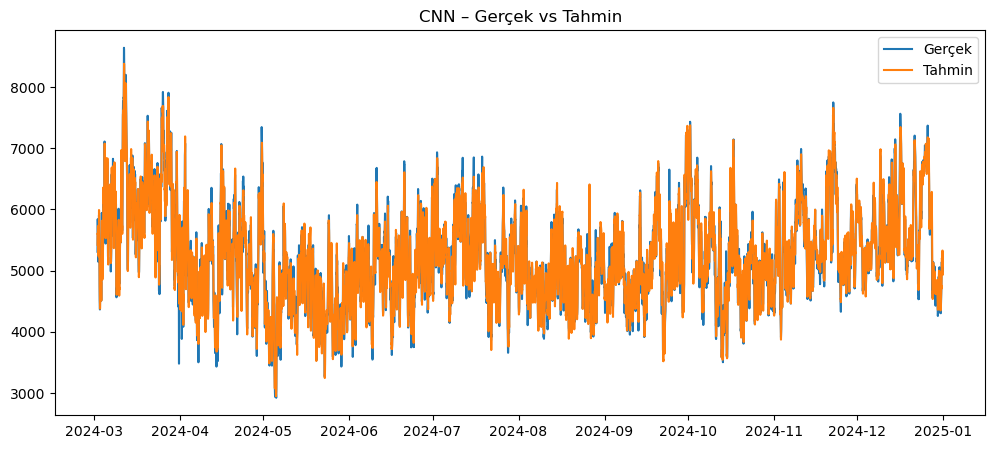

In [50]:
# Gerçek değerler ile tahmin değerlerini görselleştirme
plt.figure(figsize=(12,5))
plt.plot(y_test_realc, y_test_real_cnn, label="Gerçek")
plt.plot(y_test_realc, y_pred_cnn, label="Tahmin")
plt.legend()
plt.title("CNN – Gerçek vs Tahmin")
plt.show()

# Tüm Modellerin Karşılaştırılması

In [51]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "LSTM", "CNN"],
    "MAE":  [rf_mae, mae_xgb, mae_lgbm, lstm_mae, mae_cnn],
    "RMSE": [rf_rmse, rmse_xgb, rmse_lgbm, lstm_rmse, rmse_cnn],
    "MAPE (%)": [rf_mape, mape_xgb, mape_lgbm, lstm_mape, mape_cnn],
    "MASE": [rf_mase, mase_xgb, mase_lgbm, lstm_mase, mase_cnn]
})

results

,Model,MAE,RMSE,MAPE (%),MASE
0,Random Forest,181.532126,268.611443,2.643745,0.793943
1,XGBoost,190.662168,268.470414,2.774201,0.833874
2,LightGBM,207.905406,293.216622,2.978454,0.909288
3,LSTM,124.846589,173.605824,2.414025,0.869466
4,CNN,126.393634,167.953618,2.445288,0.880240


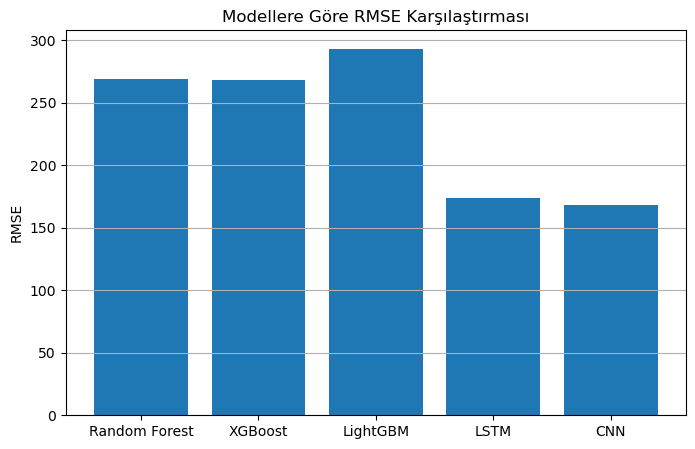

In [52]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("Modellere Göre RMSE Karşılaştırması")
plt.ylabel("RMSE")
plt.grid(axis="y")
plt.show()